# Longitudinal Modulus from Compression: Final Equilibrated State

## Theory

$$M = \frac{\sigma'_{zz}}{\varepsilon_{zz}}$$

Network stress from poroelasticity decomposition:
$$p_p(z) = -\frac{\sigma_{s,zz}(z)}{\phi_s(z)}, \qquad \sigma'_{zz}(z) = \sigma_{p,zz}(z) + \phi_p(z)\,p_p(z)$$

This notebook:
- Plots time evolution of φ, p_p, σ' to verify equilibration
- Uses **final timestep only** for M calculation
- Reports gel-averaged M with 95% CI from spatial variation

In [22]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from scipy import stats
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# CMU Serif font setup
plt.rcParams.update({
    'font.family': 'CMU Serif',
    'mathtext.fontset': 'cm',
    'mathtext.rm': 'CMU Serif',
    'font.size': 20,
    'axes.titlesize': 22,
    'axes.labelsize': 25,
    'xtick.labelsize': 23,
    'ytick.labelsize': 23,
    'legend.fontsize': 20,
    'figure.titlesize': 22,
    'axes.unicode_minus': False,   # use ASCII hyphen instead of Unicode minus
})

print('Imports successful')

Imports successful


## Configuration

In [2]:
sim_name = 'walled_slab_support_5beads_tall_4_1.0_1.05_15000000_1.0_1.05_10000000'
stress_data_dir = '../../flow_data_local/partial_stress_data/'
traj_file = f'../../flow_data_local/traj_files/gel_flow_{sim_name}.lammpstrj'
output_folder = '../../flow_data_local/flow_plots/'
binWidth = 2.0
phi_gel_threshold = 0.1
ci_level = 0.95

## Helper Functions

In [15]:
def read_ave_time_file(filepath):
    data_by_time = []
    with open(filepath, 'r') as f:
        lines = [l for l in f if not l.startswith('#') and l.strip()]
    i = 0
    while i < len(lines):
        parts = lines[i].split()
        if len(parts) == 2:
            timestep, nrows = int(parts[0]), int(parts[1])
            values = []
            for j in range(1, nrows + 1):
                if i + j < len(lines):
                    vp = lines[i + j].split()
                    if len(vp) == 2:
                        values.append(float(vp[1]))
            if values:
                data_by_time.append((timestep, np.arange(1, len(values)+1), np.array(values)))
            i += nrows + 1
        else:
            i += 1
    return data_by_time


def read_strain_file(filepath):
    rows = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'): continue
            rows.append([float(v) for v in line.split()])
    if not rows:
        raise ValueError(f'No data in {filepath}')
    if len(rows) == 2 and all(len(r)==1 for r in rows):
        return None, np.array([rows[0][0]]), np.array([rows[1][0]])
    if len(rows) == 1 and len(rows[0]) == 2:
        return None, np.array([rows[0][0]]), np.array([rows[0][1]])
    if all(len(r)==3 for r in rows):
        arr = np.array(rows)
        ts, col1, col2 = arr[:,0].astype(int).tolist(), arr[:,1], arr[:,2]
        ratio = np.nanmedian(col2) / np.nanmedian(col1)
        dL = col2 if ratio < 0.5 else col1 - col2
        return ts, col1, dL
    raise ValueError(f'Unrecognised format in {filepath}')


def read_lammpstrj_frame(filepath, frame_idx=0):
    with open(filepath) as f:
        lines = f.readlines()
    starts = [i for i,l in enumerate(lines) if 'ITEM: TIMESTEP' in l]
    if frame_idx < 0: frame_idx = len(starts) + frame_idx
    s = starts[frame_idx]
    e = starts[frame_idx+1] if frame_idx+1<len(starts) else len(lines)
    fl = lines[s:e]
    timestep = int(fl[1].strip())
    box = {'x': [float(v) for v in fl[5].split()],
           'y': [float(v) for v in fl[6].split()],
           'z': [float(v) for v in fl[7].split()]}
    atoms = [[int(p[0]),int(p[1]),int(p[2]),float(p[3]),float(p[4]),float(p[5])]
             for p in [l.split() for l in fl[9:9+int(fl[3].strip())]]]
    return timestep, box, atoms


def compute_volume_fractions_1d(atoms_data, box_bounds, bin_width, direction='z'):
    a = np.array(atoms_data)
    typ, pos = a[:,1].astype(int), a[:,3:6]
    pm, sm = (typ==1)|(typ==2), (typ==3)
    d = {'x':0,'y':1,'z':2}[direction]
    lo, hi = box_bounds[direction]
    edges = np.arange(lo, hi+bin_width, bin_width)
    centers = (edges[:-1]+edges[1:])/2
    phi_p, phi_s = np.zeros(len(centers)), np.zeros(len(centers))
    for i,(a_,b_) in enumerate(zip(edges[:-1],edges[1:])):
        mask = (pos[:,d]>=a_)&(pos[:,d]<b_)
        np_, ns_, nt = np.sum(pm&mask), np.sum(sm&mask), np.sum(mask)
        if nt>0: phi_p[i], phi_s[i] = np_/nt, ns_/nt
    return centers, phi_p, phi_s

def compute_volume_fractions_1d_voronoi(atoms_data, box_bounds, bin_width, direction='z'):
    import tess
    import time

    a = np.array(atoms_data)
    typ = a[:,1].astype(int)
    pos = a[:,3:6]

    xlo, xhi = box_bounds['x']
    ylo, yhi = box_bounds['y']
    zlo, zhi = box_bounds['z']
    L = np.array([xhi-xlo, yhi-ylo, zhi-zlo])
    origin = np.array([xlo, ylo, zlo])

    # Filter to mobile atoms only (polymer + solvent) — exclude walls/support/piston
    mobile_mask = (typ == 1) | (typ == 2) | (typ == 3)
    typ_m = typ[mobile_mask]
    pos_m = pos[mobile_mask]

    # Wrap into box
    pos_wrapped = origin + (pos_m - origin) % L

    # Check for duplicates — voro++ will fail on coincident points
    print(f'  Checking for duplicate positions...')
    _, unique_idx = np.unique(np.round(pos_wrapped, 6), axis=0, return_index=True)
    n_dupes = len(pos_wrapped) - len(unique_idx)
    if n_dupes > 0:
        print(f'  Warning: removing {n_dupes} duplicate positions')
        pos_wrapped = pos_wrapped[unique_idx]
        typ_m = typ_m[unique_idx]

    print(f'  Building Voronoi container ({len(pos_wrapped)} atoms)...')
    t0 = time.time()
    cntr = tess.Container(
        pos_wrapped,
        limits=((xlo, ylo, zlo), (xhi, yhi, zhi)),
        periodic=True
    )
    print(f'  Container built ({time.time()-t0:.1f}s)')

    print(f'  Extracting cell volumes...')
    t0 = time.time()
    voronoi_volumes = np.array([c.volume() for c in cntr])
    print(f'  Volumes extracted ({time.time()-t0:.1f}s)')

    # Sanity check
    box_vol = L[0] * L[1] * L[2]
    voro_total = np.sum(voronoi_volumes)
    if abs(voro_total - box_vol) / box_vol > 0.01:
        print(f'  Warning: Voronoi volume {voro_total:.2f} differs from box {box_vol:.2f} by '
              f'{100*abs(voro_total-box_vol)/box_vol:.1f}%')

    # Bin along direction
    d = {'x': 0, 'y': 1, 'z': 2}[direction]
    lo, hi = box_bounds[direction]
    edges   = np.arange(lo, hi + bin_width, bin_width)
    centers = (edges[:-1] + edges[1:]) / 2

    pm = (typ_m == 1) | (typ_m == 2)
    sm = (typ_m == 3)

    phi_p = np.zeros(len(centers))
    phi_s = np.zeros(len(centers))

    for i, (a_, b_) in enumerate(zip(edges[:-1], edges[1:])):
        mask    = (pos_wrapped[:, d] >= a_) & (pos_wrapped[:, d] < b_)
        V_p     = np.sum(voronoi_volumes[mask & pm])
        V_s     = np.sum(voronoi_volumes[mask & sm])
        V_total = np.sum(voronoi_volumes[mask])
        if V_total > 0:
            phi_p[i] = V_p / V_total
            phi_s[i] = V_s / V_total

    return centers, phi_p, phi_s


def mean_ci(values, ci_level=0.95):
    v = values[~np.isnan(values)]
    n = len(v)
    if n==0: return np.nan, np.nan, np.nan
    if n==1: return v[0], v[0], v[0]
    m = np.mean(v)
    lo, hi = stats.t.interval(ci_level, df=n-1, loc=m, scale=stats.sem(v))
    return m, lo, hi

def get_wall_z_positions(atoms_data):
    """
    Extract mean z-positions of support (type 4) and piston (type 5)
    from a trajectory frame.
    """
    a = np.array(atoms_data)
    typ = a[:, 1].astype(int)
    z   = a[:, 5]

    z_support = np.mean(z[typ == 4])
    z_piston  = np.mean(z[typ == 5])

    return z_support, z_piston


def compute_fourier_modes(phi_profiles, z_centers, n_modes=5,
                          z_lo_trim=None, z_hi_trim=None):
    """
    Compute cosine transform mode amplitudes for each timestep.

    phi_profiles : list of 1D arrays (n_times, n_bins)
    z_centers    : 1D array of bin centers
    n_modes      : number of modes to retain (starting from n=1)
    z_lo_trim    : lower z cutoff — bins below this are excluded
    z_hi_trim    : upper z cutoff — bins above this are excluded

    Returns
    -------
    amplitudes : (n_times, n_modes) array — |A_n(t)| for n=1..n_modes
    q_n        : (n_modes,) array of wavenumbers n*pi/L
    z_trimmed  : z_centers after trimming (for reference)
    """
    # Apply trim mask
    mask = np.ones(len(z_centers), dtype=bool)
    if z_lo_trim is not None:
        mask &= z_centers >= z_lo_trim
    if z_hi_trim is not None:
        mask &= z_centers <= z_hi_trim

    z_trim    = z_centers[mask]
    profiles  = np.array(phi_profiles)[:, mask]

    phi_eq = profiles[-1]
    delta  = profiles - phi_eq

    L   = z_trim[-1] - z_trim[0]
    N   = len(z_trim)
    q_n = np.arange(1, n_modes + 1) * np.pi / L

    z_rel      = z_trim - z_trim[0]
    amplitudes = np.zeros((len(profiles), n_modes))
    for t_idx in range(len(profiles)):
        for n_idx, n in enumerate(range(1, n_modes + 1)):
            amplitudes[t_idx, n_idx] = (2.0 / N) * np.sum(
                delta[t_idx] * np.cos(n * np.pi * z_rel / L)
            )

    return amplitudes, q_n, z_trim

def fit_diffusivity_per_mode(amplitudes, q_n, timesteps):
    """
    For each mode n, fit ln|A_n(t)| = ln|A_n(0)| - D_c * q_n^2 * t
    via linear regression to extract D_c with uncertainty.

    Returns
    -------
    results : list of dicts, one per mode, with keys:
        n, q_n, D_c, D_c_se, D_c_ci_lo, D_c_ci_hi, r_squared, slope, slope_se
    """
    from scipy import stats as sp_stats

    t = np.array(timesteps, dtype=float)
    results = []

    for n_idx in range(amplitudes.shape[1]):
        A = amplitudes[:, n_idx]

        # Only use timesteps where amplitude is non-zero and finite
        valid = (np.abs(A) > 1e-12) & np.isfinite(A)
        if np.sum(valid) < 3:
            print(f'  Mode n={n_idx+1}: insufficient valid points ({np.sum(valid)}), skipping')
            continue

        t_v   = t[valid]
        lnA_v = np.log(np.abs(A[valid]))

        slope, intercept, r, p, slope_se = sp_stats.linregress(t_v, lnA_v)
        r_squared = r**2

        # D_c = -slope / q^2,  propagate SE: D_c_se = slope_se / q^2
        q2    = q_n[n_idx]**2
        D_c   = -slope / q2
        D_c_se = slope_se / q2

        # 95% CI via t-distribution
        df     = np.sum(valid) - 2
        t_crit = sp_stats.t.ppf(0.975, df) if df > 0 else np.nan
        margin = t_crit * D_c_se

        results.append({
            'n':        n_idx + 1,
            'q_n':      q_n[n_idx],
            'D_c':      D_c,
            'D_c_se':   D_c_se,
            'D_c_ci_lo': D_c - margin,
            'D_c_ci_hi': D_c + margin,
            'r_squared': r_squared,
            'slope':    slope,
            'slope_se': slope_se,
            'n_points': int(np.sum(valid)),
        })

    return results


def combine_diffusivity_estimates(results, r2_threshold=0.5):
    """
    Weighted average of D_c across modes, weighting by R^2.
    Modes with R^2 < r2_threshold are excluded as too noisy.
    
    Returns D_c_mean, D_c_ci_lo, D_c_ci_hi, and the list of included modes.
    """
    from scipy import stats as sp_stats

    good = [r for r in results if r['r_squared'] >= r2_threshold and r['D_c'] > 0]
    if not good:
        print(f'  Warning: no modes passed R^2 threshold ({r2_threshold}). '
              f'Lowering threshold or checking data is recommended.')
        good = [r for r in results if r['D_c'] > 0]
    if not good:
        return np.nan, np.nan, np.nan, []

    weights = np.array([r['r_squared'] for r in good])
    weights /= weights.sum()
    D_vals  = np.array([r['D_c']    for r in good])
    D_ses   = np.array([r['D_c_se'] for r in good])

    D_mean   = np.sum(weights * D_vals)
    # Combined SE: sqrt of weighted sum of variances
    D_se_combined = np.sqrt(np.sum((weights * D_ses)**2))

    # Conservative df = min df across included modes
    min_df   = min(r['n_points'] - 2 for r in good)
    t_crit   = sp_stats.t.ppf(0.975, max(min_df, 1))
    margin   = t_crit * D_se_combined

    return D_mean, D_mean - margin, D_mean + margin, good

print('Helper functions defined')

Helper functions defined


## Step 1: Read All Data

In [4]:
stress_data = {}
for key, fp in [
    ('polymer_z', f'{stress_data_dir}stress_z_polymer_{sim_name}.dat'),
    ('solvent_z', f'{stress_data_dir}stress_z_solvent_{sim_name}.dat'),
]:
    print(f'Reading {key} ...')
    stress_data[key] = read_ave_time_file(fp)

n_stress = len(stress_data['polymer_z'])
print(f'\nStress snapshots: {n_stress}')

strain_file = f'{stress_data_dir}strain_zz_{sim_name}.dat'
print(f'\nReading {strain_file}')
ts_strain, L_arr, dL_arr = read_strain_file(strain_file)

if len(L_arr)==1:
    L_final, dL_final = L_arr[0], dL_arr[0]
else:
    L_final, dL_final = L_arr[-1], dL_arr[-1]

eps_final = dL_final / L_final
print(f'\nFinal: L={L_final:.4f}, ΔL={dL_final:.4f}, ε={eps_final:.4f}')

Reading polymer_z ...
Reading solvent_z ...

Stress snapshots: 21

Reading ../../flow_data_local/partial_stress_data/strain_zz_walled_slab_support_5beads_tall_4_1.0_1.05_15000000_1.0_1.05_10000000.dat

Final: L=95.8257, ΔL=15.2660, ε=0.1593


## Step 2: Process All Timesteps (for equilibration plots)

In [5]:
# Build a lookup: timestep → trajectory frame index
traj_timestep_to_frame = {}
with open(traj_file) as f:
    lines = f.readlines()
starts = [i for i,l in enumerate(lines) if 'ITEM: TIMESTEP' in l]
for frame_idx, s in enumerate(starts):
    ts = int(lines[s+1].strip())
    traj_timestep_to_frame[ts] = frame_idx

print(f'Trajectory frames available: {len(starts)}')
print(f'Trajectory timestep range: {min(traj_timestep_to_frame)} → {max(traj_timestep_to_frame)}')

# Match stress snapshots to trajectory frames by timestep
matched = []
for idx in range(len(stress_data['polymer_z'])):
    stress_ts = stress_data['polymer_z'][idx][0]
    if stress_ts in traj_timestep_to_frame:
        matched.append((idx, traj_timestep_to_frame[stress_ts]))
    else:
        # Find nearest trajectory frame
        nearest = min(traj_timestep_to_frame.keys(), key=lambda t: abs(t - stress_ts))
        print(f'  Warning: stress ts={stress_ts} not in traj, using nearest ts={nearest}')
        matched.append((idx, traj_timestep_to_frame[nearest]))

n_snapshots = len(matched)
print(f'Matched {n_snapshots} snapshots\n')

# Initialise accumulators
all_timesteps = []
all_phi_polymer = []
all_phi_solvent = []
all_p_p = []
all_sigma_p_zz = []
all_sigma_s_zz = []
all_sigma_prime_zz = []

# NOTE: volume fractions here are count-based (fast).
# Voronoi phi is computed only for the final frame in Step 4.
for count, (stress_idx, frame_idx) in enumerate(matched):
    if (count+1) % max(1, n_snapshots//10) == 0 or count == 0:
        print(f'  {count+1}/{n_snapshots}')

    _, box, atoms = read_lammpstrj_frame(traj_file, frame_idx)
    z_centers, phi_p, phi_s = compute_volume_fractions_1d(atoms, box, binWidth, 'z')

    ts = stress_data['polymer_z'][stress_idx][0]
    bins_z = stress_data['polymer_z'][stress_idx][1]
    z_coords = bins_z * binWidth - binWidth/2
    sig_p = stress_data['polymer_z'][stress_idx][2]
    sig_s = stress_data['solvent_z'][stress_idx][2]

    phi_s_safe = np.where(phi_s>1e-6, phi_s, np.nan)
    p_p = sig_s / phi_s_safe
    sig_prime = sig_p + phi_p * np.where(np.isnan(p_p), 0.0, p_p)

    all_timesteps.append(ts)
    all_phi_polymer.append(phi_p)
    all_phi_solvent.append(phi_s)
    all_p_p.append(p_p)
    all_sigma_p_zz.append(sig_p)
    all_sigma_s_zz.append(sig_s)
    all_sigma_prime_zz.append(sig_prime)

print(f'\nDone. t = {all_timesteps[0]} → {all_timesteps[-1]}')

zlo, zhi = box['z']
Lz = zhi - zlo
z_norm = (z_coords - zlo) / Lz
z_centers_norm = (z_centers - zlo) / Lz

Trajectory frames available: 11
Trajectory timestep range: 1000000 → 11000000
Matched 21 snapshots

  1/21
  2/21
  4/21
  6/21
  8/21
  10/21
  12/21
  14/21
  16/21
  18/21
  20/21

Done. t = 1000000 → 11000000


## Step 3: Equilibration Check — Time Evolution Plots

Verify φ, p_p, and σ' have reached steady-state before extracting M.

Saved: ../../flow_data_local/flow_plots/equilibration_check_walled_slab_support_5beads_tall_4_1.0_1.05_15000000_1.0_1.05_10000000.png


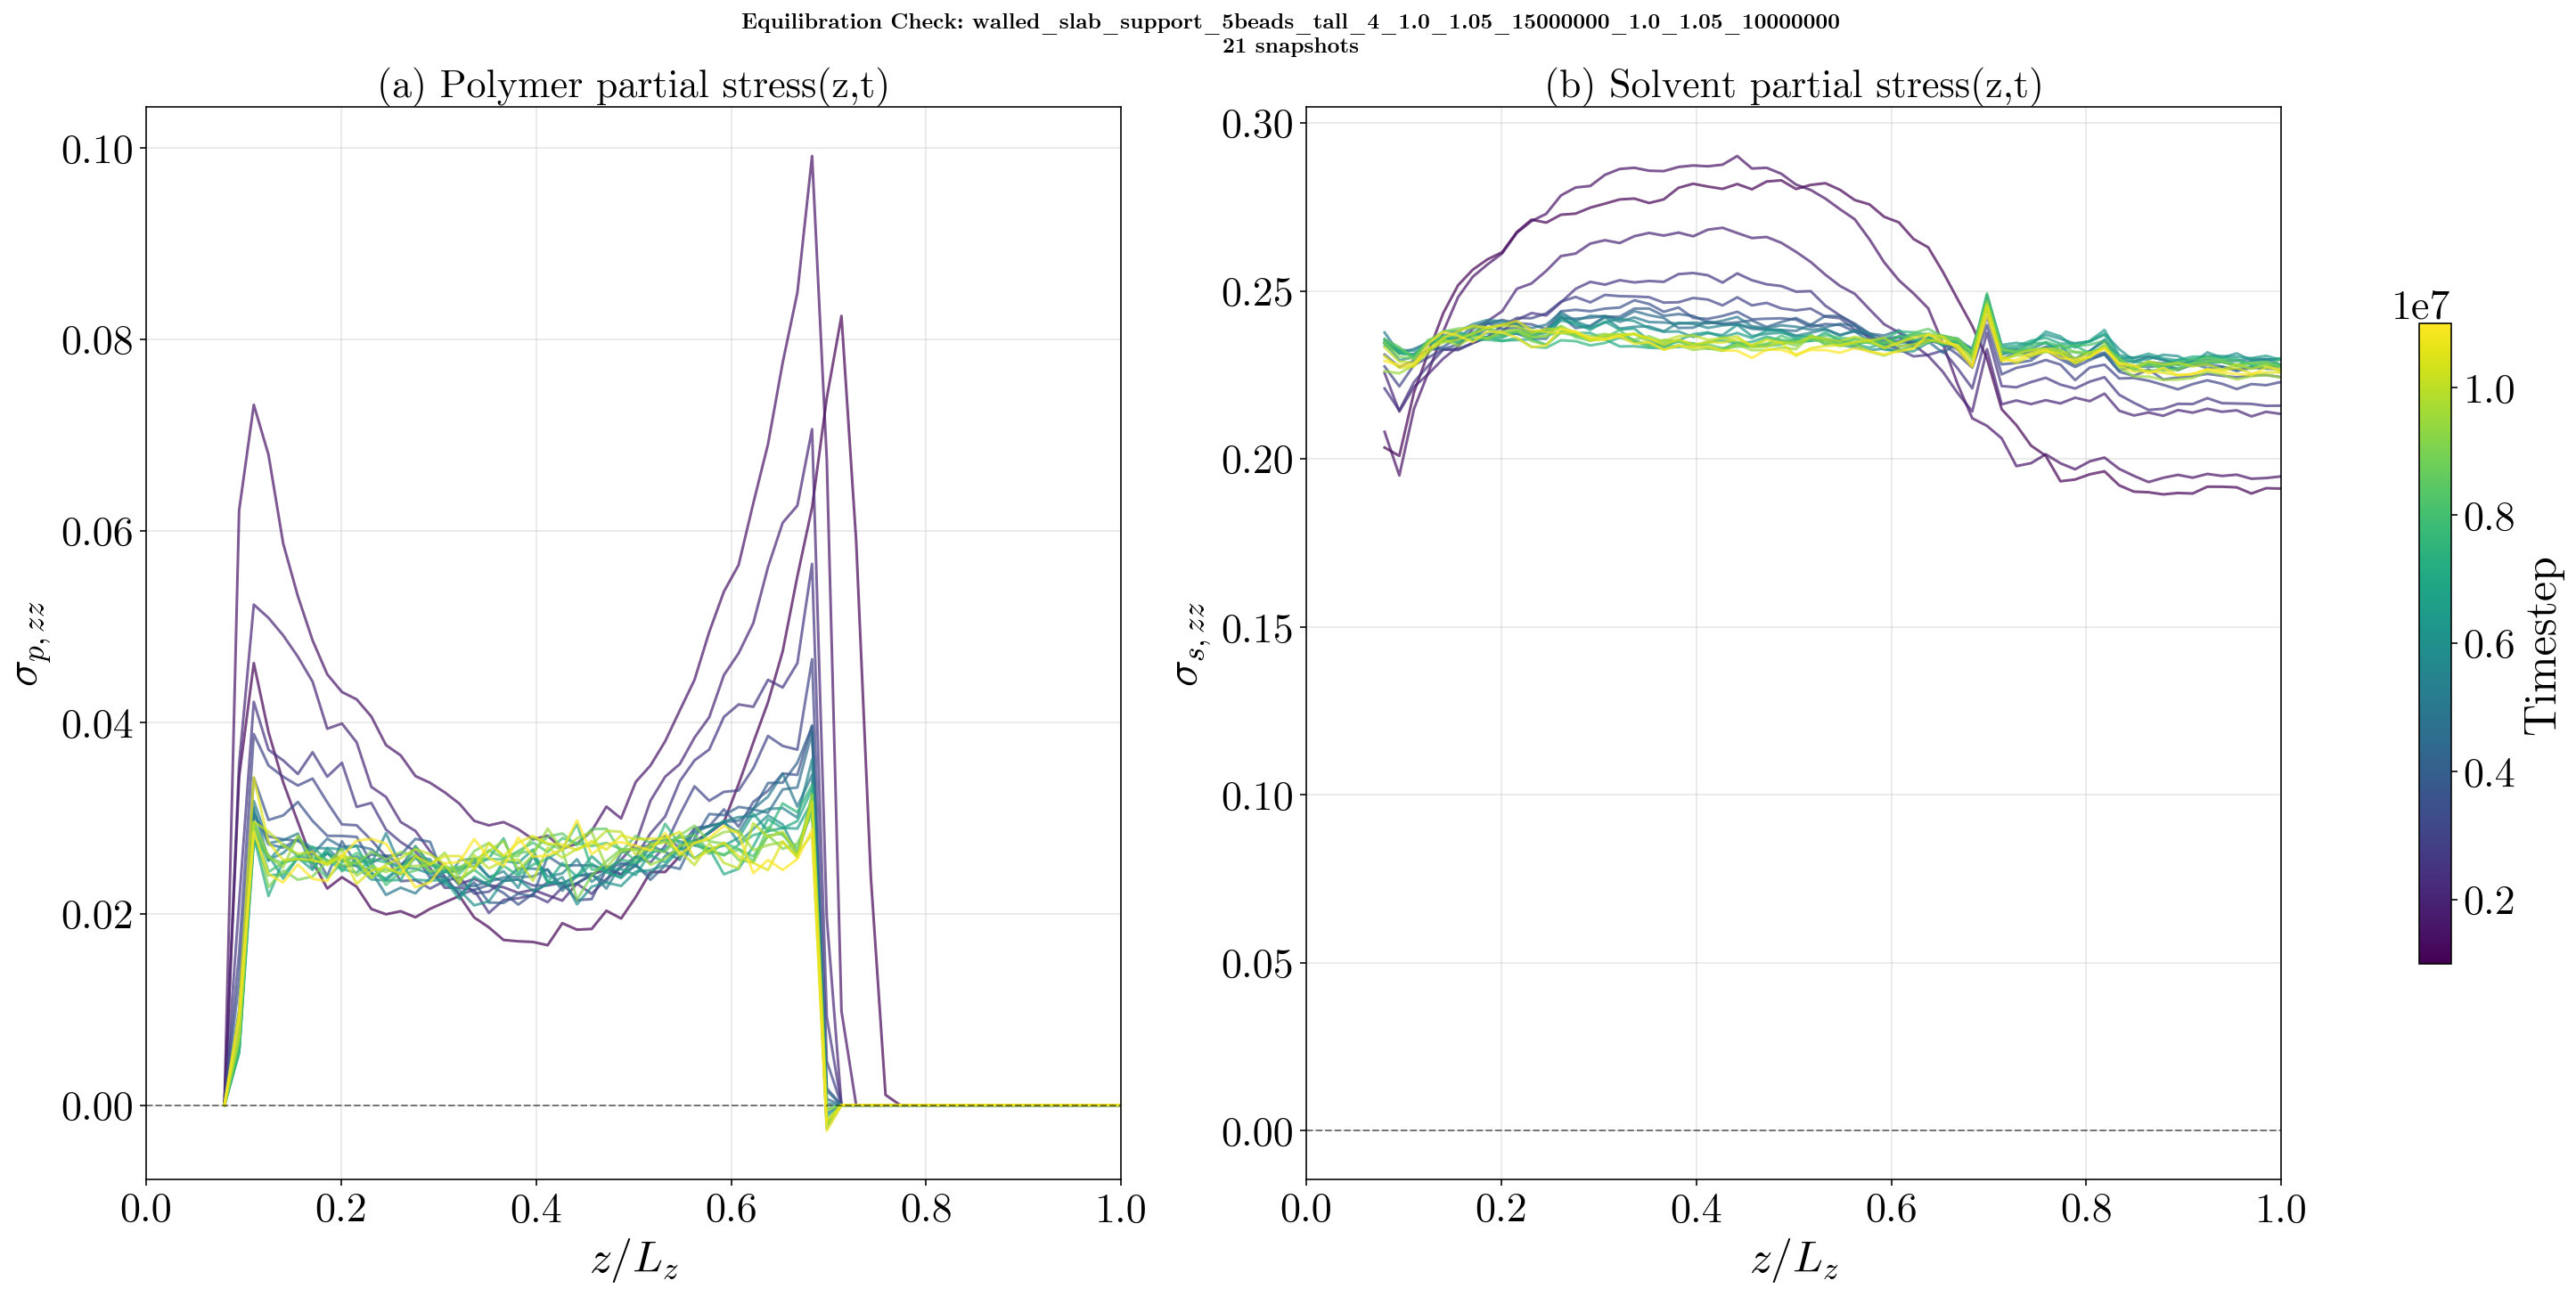

In [6]:
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

colors = plt.cm.viridis(np.linspace(0, 1, n_snapshots))
alpha = 0.7

fig = plt.figure(figsize=(20, 10), constrained_layout=True)
fig.suptitle(
    f'Equilibration Check: {sim_name}\n{n_snapshots} snapshots',
    fontsize=12, fontweight='bold')

gs = gridspec.GridSpec(1, 2, figure=fig)

ax_a = fig.add_subplot(gs[0, 0])  # Polymer partial stress
ax_b = fig.add_subplot(gs[0, 1])  # Solvent partial stress

# (a) Polymer partial stress zz
for i in range(n_snapshots):
    ax_a.plot(z_norm, all_sigma_p_zz[i], '-', color=colors[i], lw=1.5, alpha=alpha)
ax_a.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax_a.set(xlabel='$z/L_z$', ylabel=r'$\sigma_{p,zz}$', title=r'(a) Polymer partial stress(z,t)', xlim=(0,1))
ax_a.grid(alpha=0.3)

# (b) Solvent partial stress zz
for i in range(n_snapshots):
    ax_b.plot(z_norm, all_sigma_s_zz[i], '-', color=colors[i], lw=1.5, alpha=alpha)
ax_b.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax_b.set(xlabel='$z/L_z$', ylabel=r'$\sigma_{s,zz}$', title=r'(b) Solvent partial stress(z,t)', xlim=(0,1))
ax_b.grid(alpha=0.3)

# Colorbar
sm = plt.cm.ScalarMappable(cmap='viridis',
                            norm=Normalize(vmin=all_timesteps[0], vmax=all_timesteps[-1]))
sm.set_array([])
cb = fig.colorbar(sm, ax=[ax_a, ax_b], fraction=0.015, pad=0.04)
cb.set_label('Timestep')

out1 = Path(output_folder) / f'equilibration_check_{sim_name}.png'
plt.savefig(out1, dpi=150, bbox_inches='tight')
print(f'Saved: {out1}')
plt.show()

Support z: -8.511,  Piston z: 74.493
Trim range: [-5.511, 71.493]
Saved: ../../flow_data_local/flow_plots/volfrac_evolution_walled_slab_support_5beads_tall_4_1.0_1.05_15000000_1.0_1.05_10000000.png


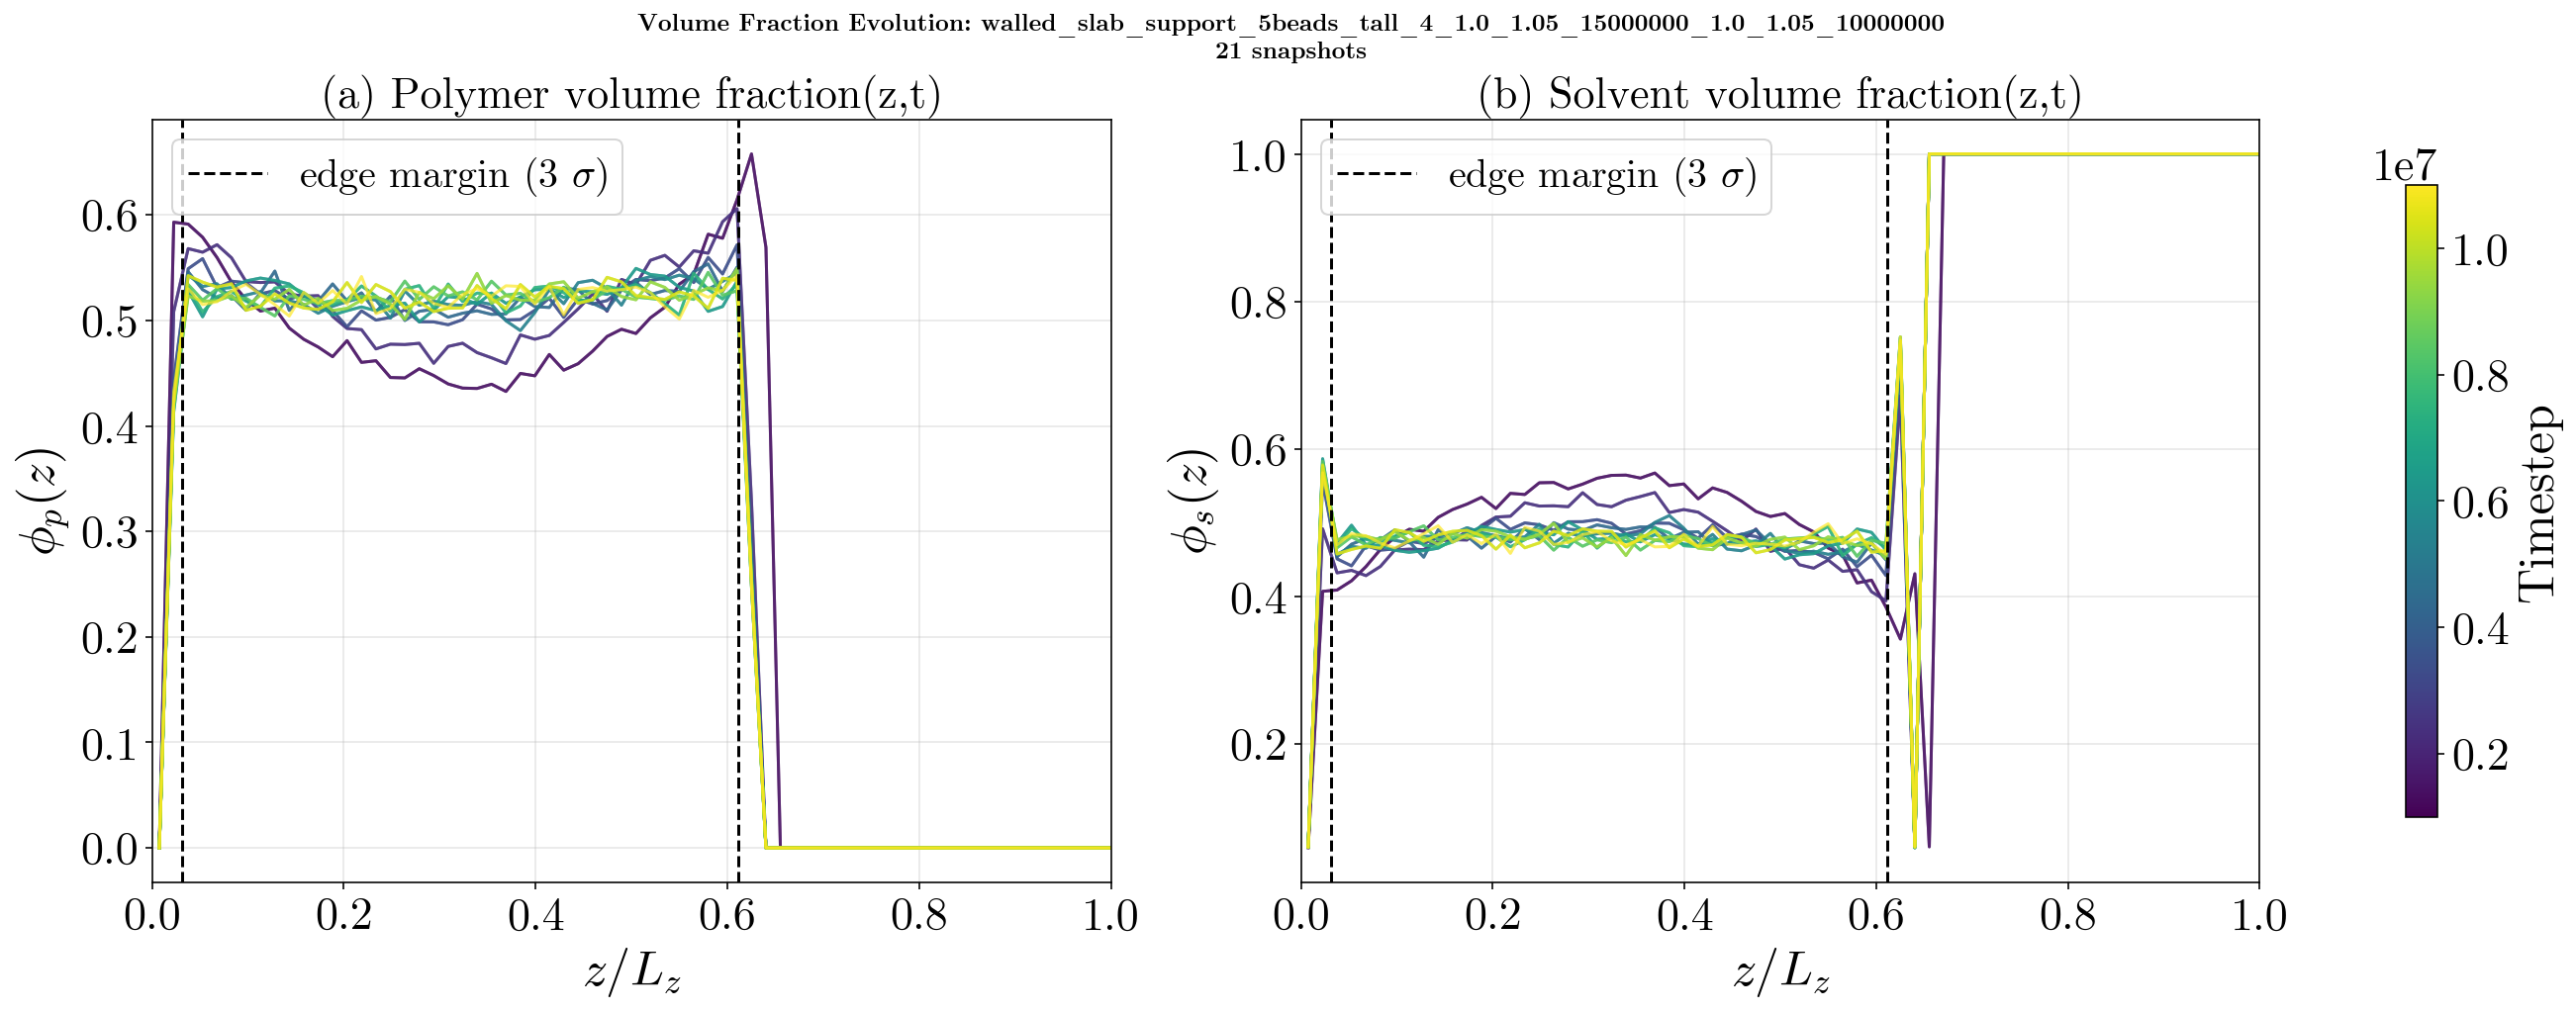

In [28]:
# --- Get trim bounds from final frame (also used by diffusivity cell) ---
EDGE_MARGIN = 3   # σ — keep consistent with diffusivity cell
_, _, _atoms_walls = read_lammpstrj_frame(traj_file, matched[-1][1])
z_support, z_piston = get_wall_z_positions(_atoms_walls)
z_lo_trim = z_support + EDGE_MARGIN
z_hi_trim = z_piston  - EDGE_MARGIN

# Convert trim bounds to normalised z for plotting
zlo_box, zhi_box = box['z']
Lz_box = zhi_box - zlo_box
z_lo_trim_norm = (z_lo_trim - zlo_box) / Lz_box
z_hi_trim_norm = (z_hi_trim - zlo_box) / Lz_box

print(f'Support z: {z_support:.3f},  Piston z: {z_piston:.3f}')
print(f'Trim range: [{z_lo_trim:.3f}, {z_hi_trim:.3f}]')

# --- Volume fraction evolution figure ---
fig_vf, axes_vf = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
fig_vf.suptitle(
    f'Volume Fraction Evolution: {sim_name}\n{n_snapshots} snapshots',
    fontsize=12, fontweight='bold')

# Polymer volume fraction
ax = axes_vf[0]
for i in range(n_snapshots):
    ax.plot(z_centers_norm, all_phi_polymer[i], '-', color=colors[i], lw=1.5, alpha=alpha)
ax.axvline(z_lo_trim_norm, color='k', ls='--', lw=1.5, label=f'edge margin ({EDGE_MARGIN} $\\sigma$)')
ax.axvline(z_hi_trim_norm, color='k', ls='--', lw=1.5)
ax.legend()
ax.set(xlabel='$z/L_z$', ylabel=r'$\phi_p(z)$', title='(a) Polymer volume fraction(z,t)', xlim=(0,1))
ax.grid(alpha=0.3)

# Solvent volume fraction
ax = axes_vf[1]
for i in range(n_snapshots):
    ax.plot(z_centers_norm, all_phi_solvent[i], '-', color=colors[i], lw=1.5, alpha=alpha)
ax.axvline(z_lo_trim_norm, color='k', ls='--', lw=1.5, label=f'edge margin ({EDGE_MARGIN} $\\sigma$)')
ax.axvline(z_hi_trim_norm, color='k', ls='--', lw=1.5)
ax.legend()
ax.set(xlabel='$z/L_z$', ylabel=r'$\phi_s(z)$', title='(b) Solvent volume fraction(z,t)', xlim=(0,1))
ax.grid(alpha=0.3)

# Colorbar
sm_vf = plt.cm.ScalarMappable(cmap='viridis',
                               norm=Normalize(vmin=all_timesteps[0], vmax=all_timesteps[-1]))
sm_vf.set_array([])
cb_vf = fig_vf.colorbar(sm_vf, ax=axes_vf, fraction=0.015, pad=0.04)
cb_vf.set_label('Timestep')

out_vf = Path(output_folder) / f'volfrac_evolution_{sim_name}.png'
plt.savefig(out_vf, dpi=150, bbox_inches='tight')
print(f'Saved: {out_vf}')
plt.show()

### Step 3b: Cooperative diffusivity from volume fraction evolution plots

Support z:  -8.511
Piston  z:  74.493
Trim range: [-5.511, 71.493]  (margin = 3 σ)
Bins after trimming: 39 / 67
Fitting D_c per mode:
  n= 1  q=0.0413  D_c=1.4114e-04 ± 8.3739e-05  R²=0.136  CI=[-3.4785e-05, 3.1707e-04]  (n_pts=20)
  n= 2  q=0.0827  D_c=6.8087e-05 ± 9.1617e-06  R²=0.754  CI=[4.8839e-05, 8.7335e-05]  (n_pts=20)
  n= 3  q=0.1240  D_c=1.0059e-05 ± 5.4056e-06  R²=0.161  CI=[-1.2980e-06, 2.1416e-05]  (n_pts=20)
  n= 4  q=0.1653  D_c=1.8317e-05 ± 4.1028e-06  R²=0.525  CI=[9.6973e-06, 2.6937e-05]  (n_pts=20)
  n= 5  q=0.2067  D_c=-4.6548e-06 ± 1.7921e-06  R²=0.273  CI=[-8.4198e-06, -8.8986e-07]  (n_pts=20)

Combined D_c (R² ≥ 0.5, modes [2, 4]):
  D_c = 4.7650e-05  95% CI = [3.5766e-05, 5.9533e-05]
Saved: ../../flow_data_local/flow_plots/mode_decay_walled_slab_support_5beads_tall_4_1.0_1.05_15000000_1.0_1.05_10000000.png


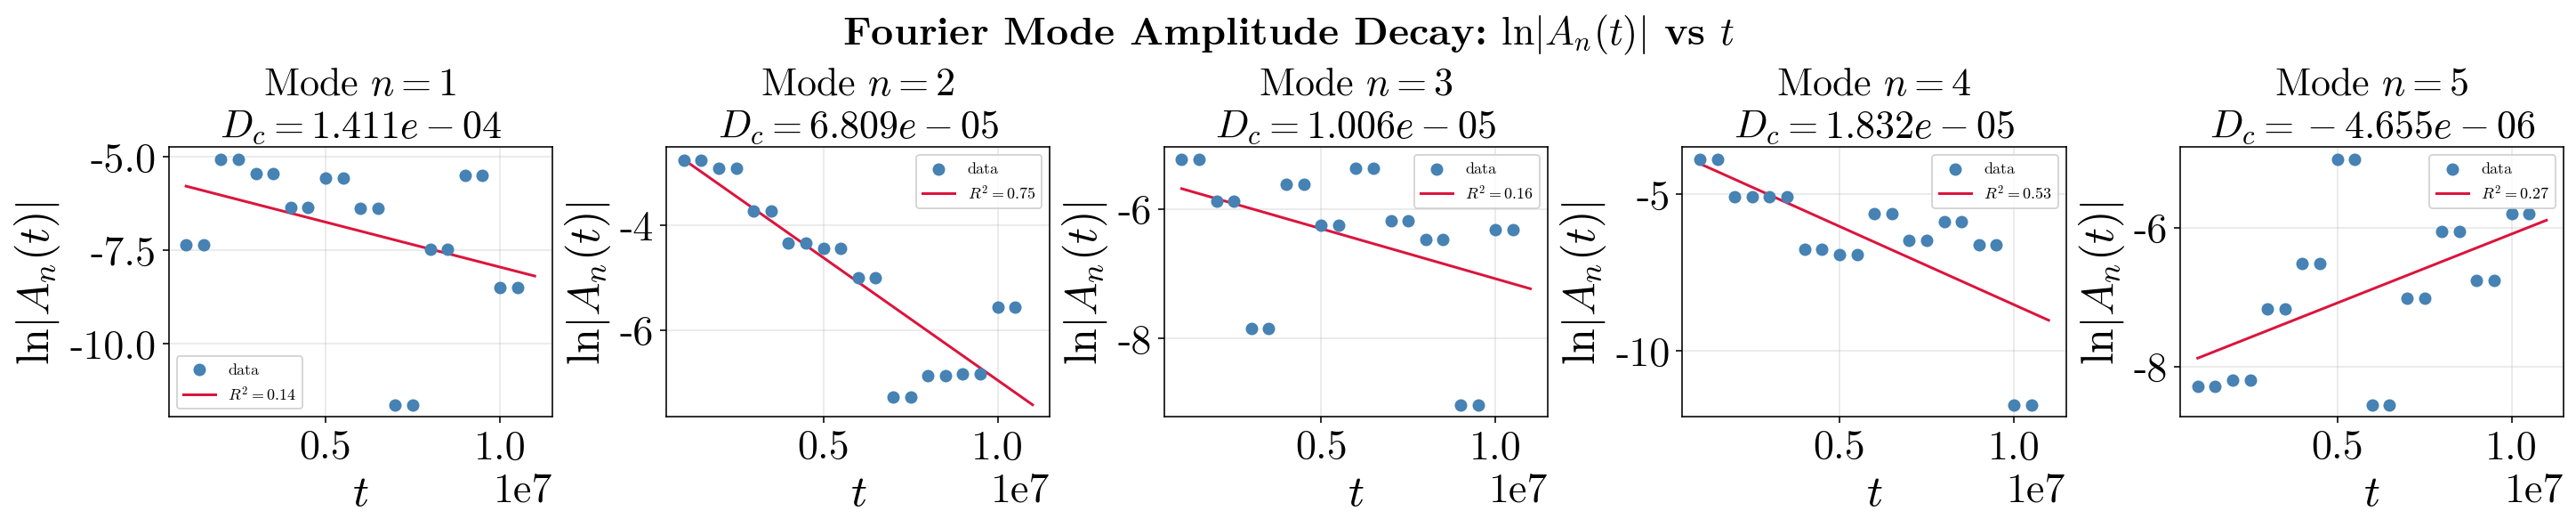

Saved: ../../flow_data_local/flow_plots/diffusivity_walled_slab_support_5beads_tall_4_1.0_1.05_15000000_1.0_1.05_10000000.png


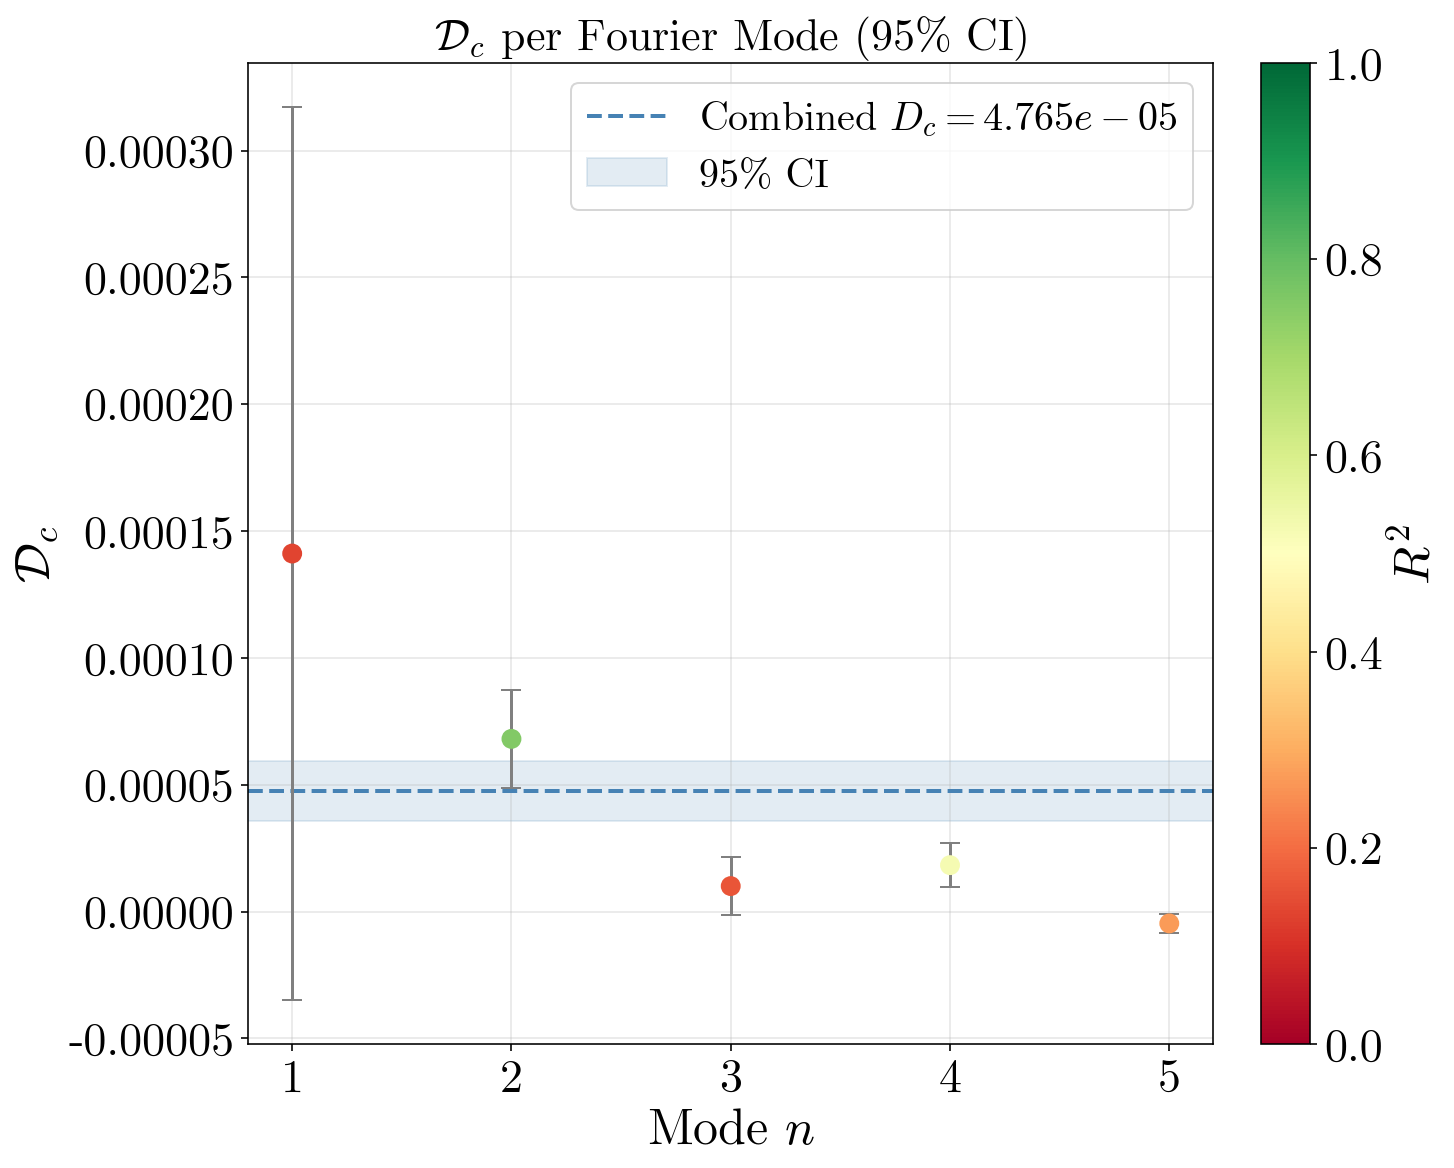

In [31]:
# ============================================================
# Cooperative Diffusivity from Fourier Mode Decay
# ============================================================
N_MODES     = 5
R2_THRESH   = 0.5
# EDGE_MARGIN from previous cell
idx_final   = -1

# --- Get piston and support z-positions from final trajectory frame ---
_, _, atoms_final_walls = read_lammpstrj_frame(traj_file, matched[idx_final][1])
z_support, z_piston = get_wall_z_positions(atoms_final_walls)

z_lo_trim = z_support + EDGE_MARGIN
z_hi_trim = z_piston  - EDGE_MARGIN

print(f'Support z:  {z_support:.3f}')
print(f'Piston  z:  {z_piston:.3f}')
print(f'Trim range: [{z_lo_trim:.3f}, {z_hi_trim:.3f}]  (margin = {EDGE_MARGIN} σ)')

# --- Compute mode amplitudes ---
amplitudes, q_n, z_trimmed = compute_fourier_modes(
    all_phi_polymer, z_centers,
    n_modes=N_MODES,
    z_lo_trim=z_lo_trim,
    z_hi_trim=z_hi_trim)

print(f'Bins after trimming: {len(z_trimmed)} / {len(z_centers)}')

# --- Fit D_c per mode ---
print('Fitting D_c per mode:')
mode_results = fit_diffusivity_per_mode(amplitudes, q_n, all_timesteps)

for r in mode_results:
    print(f"  n={r['n']:2d}  q={r['q_n']:.4f}  D_c={r['D_c']:.4e} "
          f"± {r['D_c_se']:.4e}  R²={r['r_squared']:.3f}  "
          f"CI=[{r['D_c_ci_lo']:.4e}, {r['D_c_ci_hi']:.4e}]  "
          f"(n_pts={r['n_points']})")

# --- Weighted combination ---
D_mean, D_lo, D_hi, good_modes = combine_diffusivity_estimates(
    mode_results, r2_threshold=R2_THRESH)

print(f'\nCombined D_c (R² ≥ {R2_THRESH}, modes {[r["n"] for r in good_modes]}):')
print(f'  D_c = {D_mean:.4e}  95% CI = [{D_lo:.4e}, {D_hi:.4e}]')

# ---- Plot 1: Mode amplitude decay ----
fig_modes, axes_m = plt.subplots(1, N_MODES, figsize=(4*N_MODES, 4),
                                  constrained_layout=True)
fig_modes.suptitle(r'Fourier Mode Amplitude Decay: $\ln|A_n(t)|$ vs $t$',
                   fontweight='bold')

t_arr  = np.array(all_timesteps, dtype=float)
t_fine = np.linspace(t_arr.min(), t_arr.max(), 200)

for ax, r in zip(axes_m, mode_results):
    A = amplitudes[:, r['n'] - 1]
    valid = (np.abs(A) > 1e-12) & np.isfinite(A)
    lnA = np.full_like(A, np.nan)
    lnA[valid] = np.log(np.abs(A[valid]))

    ax.scatter(t_arr[valid], lnA[valid], color='steelblue', zorder=5, label='data')

    # Overlay regression line
    slope, intercept = r['slope'], -r['slope'] * t_arr[valid][0] + np.log(np.abs(A[valid][0]))
    # recompute intercept cleanly
    intercept_fit = np.mean(lnA[valid]) - r['slope'] * np.mean(t_arr[valid])
    ax.plot(t_fine, r['slope'] * t_fine + intercept_fit,
            color='crimson', lw=1.5,
            label=f"$R^2={r['r_squared']:.2f}$")

    ax.set(xlabel='$t$',
           ylabel=r'$\ln|A_n(t)|$',
           title=f"Mode $n={r['n']}$\n$D_c={r['D_c']:.3e}$")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

out_modes = Path(output_folder) / f'mode_decay_{sim_name}.png'
plt.savefig(out_modes, dpi=150, bbox_inches='tight')
print(f'Saved: {out_modes}')
plt.show()

# ---- Plot 2: D_c per mode with error bars ----
fig_dc, ax_dc = plt.subplots(figsize=(10, 8), constrained_layout=True)

ns      = [r['n']        for r in mode_results]
Dc_vals = [r['D_c']      for r in mode_results]
Dc_lo   = [r['D_c']  - r['D_c_ci_lo'] for r in mode_results]
Dc_hi   = [r['D_c_ci_hi'] - r['D_c']  for r in mode_results]
r2_vals = [r['r_squared'] for r in mode_results]

# Colour by R^2
sc = ax_dc.scatter(ns, Dc_vals, c=r2_vals, cmap='RdYlGn', vmin=0, vmax=1,
                   s=80, zorder=5)
ax_dc.errorbar(ns, Dc_vals, yerr=[Dc_lo, Dc_hi],
               fmt='none', color='gray', capsize=5, lw=1.5, zorder=4)

# Combined estimate band
if not np.isnan(D_mean):
    ax_dc.axhline(D_mean, color='steelblue', lw=2, ls='--',
                  label=f'Combined $D_c = {D_mean:.3e}$')
    ax_dc.axhspan(D_lo, D_hi, alpha=0.15, color='steelblue', label='95% CI')

cb = fig_dc.colorbar(sc, ax=ax_dc)
cb.set_label('$R^2$')
ax_dc.set(xlabel='Mode $n$', ylabel=r'$\mathcal{D}_c$',
          title=r'$\mathcal{D}_c$ per Fourier Mode (95% CI)',
          xticks=ns)
ax_dc.legend()
ax_dc.grid(alpha=0.3)

out_dc = Path(output_folder) / f'diffusivity_{sim_name}.png'
plt.savefig(out_dc, dpi=150, bbox_inches='tight')
print(f'Saved: {out_dc}')
plt.show()

## Steps 4 & 5: Final-State Profiles

Voronoi volume fractions computed once for the final frame, used for all derived quantities and plots.

In [ ]:
from scipy.interpolate import interp1d

idx_final = -1

# Stress components from LAMMPS
sig_p_final = all_sigma_p_zz[idx_final]
sig_s_final = all_sigma_s_zz[idx_final]

# --- Voronoi volume fractions (computed once) ---
print('Computing Voronoi volume fractions for final frame...')
_, box_final, atoms_final = read_lammpstrj_frame(traj_file, matched[idx_final][1])
box_bounds_final = {'x': box_final['x'], 'y': box_final['y'], 'z': box_final['z']}

z_vor, phi_p_vor, phi_s_vor = compute_volume_fractions_1d_voronoi(
    atoms_final, box_bounds_final, binWidth, 'z')

# Voronoi z grid normalised
zlo_f, zhi_f = box_final['z']
Lz_f = zhi_f - zlo_f
z_vor_norm = (z_vor - zlo_f) / Lz_f

# Interpolate Voronoi phi onto the stress bin grid
phi_p_final = interp1d(z_vor, phi_p_vor, bounds_error=False, fill_value=0.0)(z_coords)
phi_s_final = interp1d(z_vor, phi_s_vor, bounds_error=False, fill_value=0.0)(z_coords)


In [ ]:
# --- Recompute derived quantities using Voronoi phi ---
phi_s_final_safe = np.where(phi_s_final > 1e-6, phi_s_final, np.nan)
p_p_final       = sig_s_final / phi_s_final_safe
sig_prime_final  = sig_p_final + phi_p_final * np.where(np.isnan(p_p_final), 0.0, p_p_final)

if abs(eps_final) < 1e-12:
    raise ValueError('Final strain ≈ 0 — cannot compute M')

M_final = sig_prime_final / eps_final

# --- Count-based phi (for comparison plot only) ---
z_cnt, phi_p_cnt, phi_s_cnt = compute_volume_fractions_1d(
    atoms_final, box_bounds_final, binWidth, 'z')

# --- Plot 1: Count-based vs Voronoi comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle('Count-based vs Voronoi Volume Fractions (final frame)', fontweight='bold')

for ax, (phi_p, phi_s, z, label) in zip(axes, [
    (phi_p_cnt, phi_s_cnt, z_cnt, 'Count-based'),
    (phi_p_vor, phi_s_vor, z_vor, 'Voronoi')
]):
    ax.plot((z - zlo_f)/Lz_f, phi_p, 'o-', color='steelblue', ms=3, label=r'$\phi_p$')
    ax.plot((z - zlo_f)/Lz_f, phi_s, 's--', color='coral',    ms=3, label=r'$\phi_s$')
    ax.legend()
    ax.set(xlabel='$z/L_z$', ylabel='Volume Fraction', title=label, xlim=(0,1))
    ax.grid(alpha=0.3)

plt.savefig(Path(output_folder) / f'volfrac_comparison_{sim_name}.png', dpi=150)
plt.show()

fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
fig2.suptitle(
    f'Final Equilibrated State (Voronoi φ): {sim_name}\nt = {all_timesteps[idx_final]}',
    fontsize=12, fontweight='bold')

# (a) φ
ax = axes2[0, 0]
ax.plot(z_vor_norm, phi_p_vor, 'o-', label=r'$\phi_p$', color='steelblue', ms=3)
ax.plot(z_vor_norm, phi_s_vor, 's--', label=r'$\phi_s$', color='coral', ms=3)
ax.legend()
ax.set(xlabel='$z/L_z$', ylabel='$\phi(z)$', title='(a) Volume fraction', xlim=(0,1))
ax.grid(alpha=0.3)

# (b) p_p
ax = axes2[0, 1]
ax.plot(z_norm, p_p_final, 'o-', color='green', ms=3)
ax.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax.set(xlabel='$z/L_z$', ylabel=r'$p_p$', title='(b) Pore Pressure(z)', xlim=(0,1))
ax.grid(alpha=0.3)

# (c) σ'
ax = axes2[1, 0]
ax.plot(z_norm, sig_prime_final, 'o-', color='purple', ms=3)
ax.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax.set(xlabel='$z/L_z$', ylabel=r"$\sigma'_{zz}$", title=r"(c) Network Stress(z)", xlim=(0,1))
ax.grid(alpha=0.3)

# (d) M
ax = axes2[1, 1]
ax.plot(z_norm, M_final, 'o-', color='crimson', ms=3)
ax.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax.set(xlabel='$z/L_z$', ylabel='$M$',
       title=r'(d) Longitudinal modulus = $\sigma^{\prime}_{zz}/\varepsilon$', xlim=(0,1))
ax.grid(alpha=0.3)

out2 = Path(output_folder) / f'final_state_profiles_{sim_name}.png'
plt.savefig(out2, dpi=150, bbox_inches='tight')
print(f'Saved: {out2}')
plt.show()

## Step 6: Gel-Averaged M with Confidence Interval

**Procedure:**
1. Identify gel bins: where φ_p > threshold (0.05)
2. Extract M values from those bins: $\{M_1, M_2, \dots, M_n\}$
3. Compute sample mean: $\bar{M} = \frac{1}{n}\sum M_i$
4. Compute standard error: $\text{SEM} = s / \sqrt{n}$ where $s = \sqrt{\frac{1}{n-1}\sum(M_i - \bar{M})^2}$
5. Construct 95% CI using t-distribution with $n-1$ degrees of freedom:
   $$\text{CI} = \bar{M} \pm t_{0.975, n-1} \times \text{SEM}$$

**Interpretation:** The CI reflects **spatial heterogeneity** in the gel's stiffness.
Narrow band = uniform; wide band = some bins are stiffer/softer than average.

In [ ]:
print('='*70)
print('DERIVATION OF GEL-AVERAGED LONGITUDINAL MODULUS')
print('='*70)

# Step 1: Identify gel bins using Voronoi phi_p (interpolated onto stress grid)
gel_mask = phi_p_final > phi_gel_threshold
n_gel_bins = np.sum(gel_mask)
print(f'\n1. Gel bins identified: {n_gel_bins} / {len(phi_p_final)} (φ_p > {phi_gel_threshold})')

# Step 2: Extract M values
M_gel = M_final[gel_mask]
M_gel = M_gel[~np.isnan(M_gel)]  # remove any NaNs
n_valid = len(M_gel)
print(f'   Valid M values: {n_valid}')
print(f'   M_gel range: [{M_gel.min():.4f}, {M_gel.max():.4f}]')

if n_valid == 0:
    raise ValueError('No valid M values in gel region')

# Step 3: Sample mean
M_mean = np.mean(M_gel)
print(f'\n2. Sample mean: M̄ = {M_mean:.6f}')

# Step 4: Standard error
if n_valid == 1:
    print('\n   WARNING: only 1 data point — CI = point estimate')
    M_ci_lo, M_ci_hi = M_mean, M_mean
else:
    s = np.std(M_gel, ddof=1)  # sample std dev
    sem = stats.sem(M_gel)     # s / sqrt(n)
    print(f'\n3. Sample std dev: s = {s:.6f}')
    print(f'   Standard error: SEM = s/√n = {sem:.6f}')

    # Step 5: t-distribution CI
    df = n_valid - 1
    t_crit = stats.t.ppf((1+ci_level)/2, df)
    margin = t_crit * sem
    M_ci_lo = M_mean - margin
    M_ci_hi = M_mean + margin

    print(f'\n4. t-distribution (df={df}, α={1-ci_level}):')
    print(f'   Critical value: t_{{0.975, {df}}} = {t_crit:.4f}')
    print(f'   Margin of error: {margin:.6f}')

ci_pct = int(ci_level*100)
print(f'\n{"="*70}')
print(f'FINAL RESULT ({ci_pct}% Confidence Interval)')
print(f'{"="*70}')
print(f'  M = {M_mean:.4f}  [{M_ci_lo:.4f}, {M_ci_hi:.4f}]')
print(f'\nStrain: ε_zz = {eps_final:.4f}')
print(f'Gel thickness: L = {L_final:.2f}, ΔL = {dL_final:.2f}')
print('='*70)

## Optional: Save Data

In [ ]:
out_data = Path(output_folder) / f'longitudinal_modulus_final_{sim_name}.npz'
np.savez(out_data,
         z_coords=z_coords, z_norm=z_norm,
         z_centers=z_centers, z_centers_norm=z_centers_norm,
         z_vor=z_vor, z_vor_norm=z_vor_norm,
         final_timestep=all_timesteps[idx_final],
         L=L_final, dL=dL_final, eps=eps_final,
         phi_p=phi_p_final, phi_s=phi_s_final,
         phi_p_vor=phi_p_vor, phi_s_vor=phi_s_vor,
         p_p=p_p_final, sigma_p_zz=sig_p_final, sigma_s_zz=sig_s_final,
         sigma_prime_zz=sig_prime_final, M=M_final,
         M_mean=M_mean, M_ci_lo=M_ci_lo, M_ci_hi=M_ci_hi,
         ci_level=ci_level, n_gel_bins=n_gel_bins,
         sim_name=sim_name)
print(f'Saved: {out_data}')